Day Animal: 498 images
Day Civilian: 499 images
Day Soldier: 406 images
Night Animal: 421 images


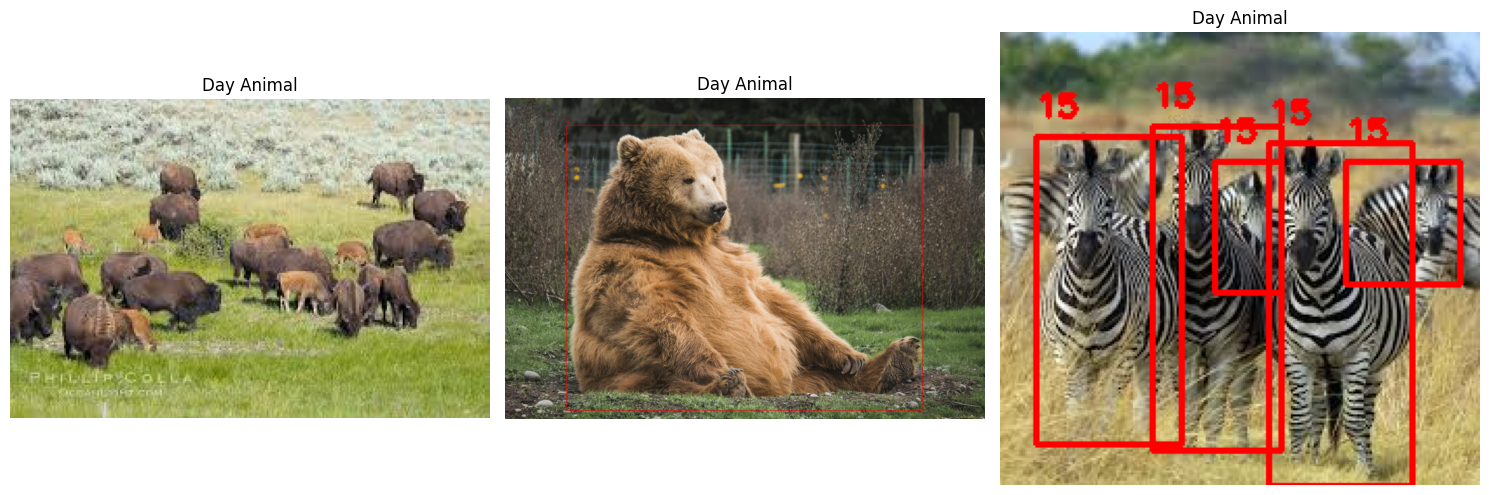

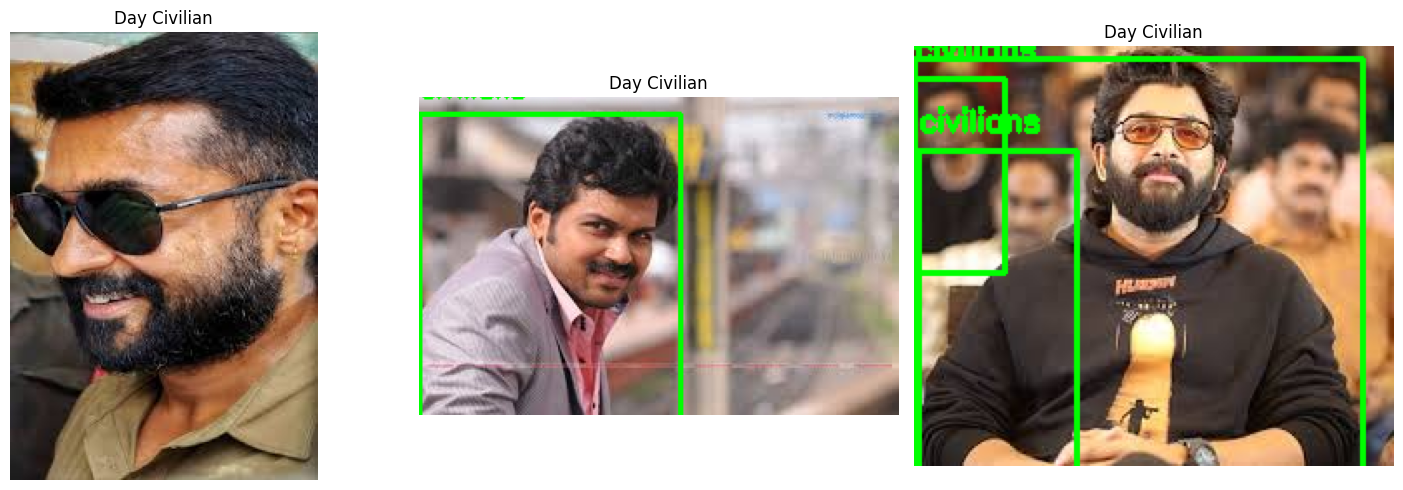

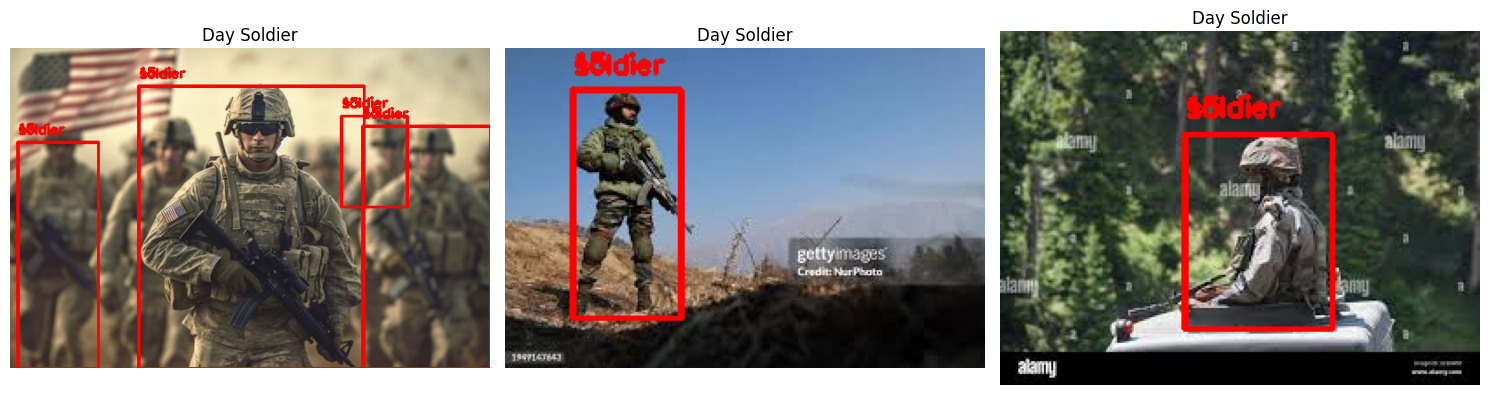

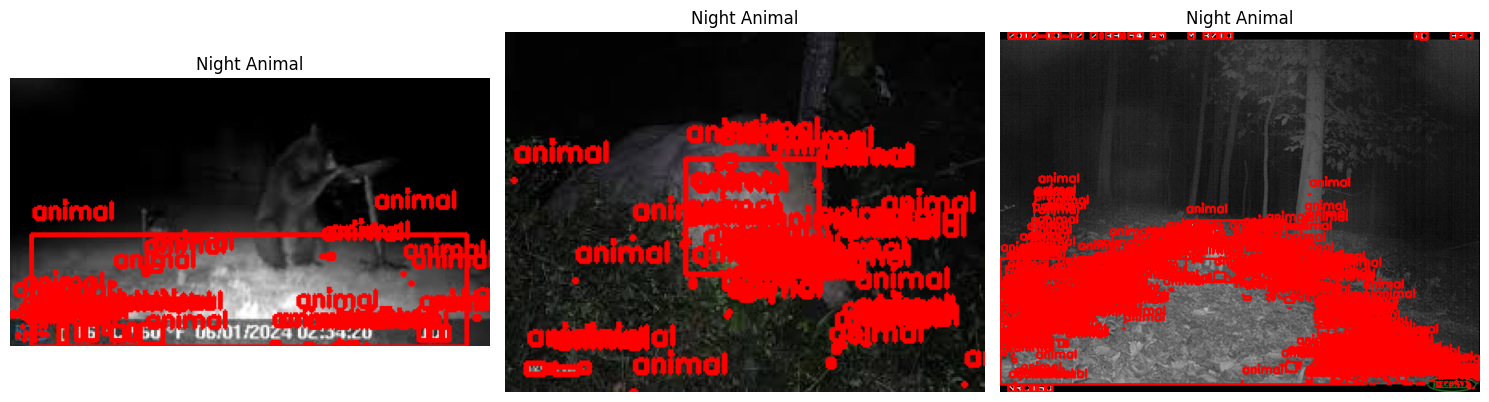

In [4]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import xml.etree.ElementTree as ET

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = float(bndbox.find('xmin').text)
        ymin = float(bndbox.find('ymin').text)
        xmax = float(bndbox.find('xmax').text)
        ymax = float(bndbox.find('ymax').text)
        
        width = xmax - xmin
        height = ymax - ymin
        x_center = xmin + width/2
        y_center = ymin + height/2
        
        boxes.append({'class': class_name, 'coords': [x_center, y_center, width, height]})
    return boxes

def parse_txt(txt_path):
    boxes = []
    if not os.path.exists(txt_path):
        return boxes
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_name = parts[0]
                coords = [float(x) for x in parts[1:5]]
                boxes.append({'class': class_name, 'coords': coords})
    return boxes

def detect_objects_simple(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_height, img_width = img.shape[:2]
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        x_center = (x + w / 2) / img_width
        y_center = (y + h / 2) / img_height
        width = w / img_width
        height = h / img_height
        boxes.append({'class': 'animal', 'coords': [x_center, y_center, width, height]})
    return boxes

def load_dataset(path, category):
    images, labels = [], []
    img_paths = glob(os.path.join(path, '**', '*.jpg'), recursive=True)
    img_paths.extend(glob(os.path.join(path, '**', '*.png'), recursive=True))
    
    for img_path in img_paths:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
            boxes = []
            if category == 'animal' and 'Day' in path:
                txt_path = os.path.join('/kaggle/input/defence-dataset/Dataset/Classification/Day/animal/txt', os.path.basename(img_path).replace('.jpg', '.txt').replace('.png', '.txt'))
                boxes = parse_txt(txt_path)
            elif category == 'soldier':
                xml_path = img_path.replace('images', 'labels/xml').replace('.jpg', '.xml').replace('.png', '.xml')
                boxes.extend(parse_xml(xml_path) if os.path.exists(xml_path) else [])
                txt_path = img_path.replace('images', 'labels/text').replace('.jpg', '.txt').replace('.png', '.txt')
                boxes.extend(parse_txt(txt_path))
            elif category == 'animal' and 'Night' in path:
                boxes = detect_objects_simple(img)
            else:
                txt_path = img_path.replace('images', 'labels').replace('.jpg', '.txt').replace('.png', '.txt')
                boxes = parse_txt(txt_path)
            
            labels.append(boxes if boxes else None)
    return images, labels

def draw_boxes(img, boxes):
    img_copy = img.copy()
    img_height, img_width = img.shape[:2]
    
    colors = {'animal': (255, 0, 0), 'civilians': (0, 255, 0), 'soldiers': (0, 0, 255)}
    
    for box in boxes:
        coords = box['coords']
        class_name = box['class'].lower()
        color = colors.get(class_name, (255, 0, 0))
        
        x_center, y_center, width, height = coords
        if x_center <= 1.0:
            x_center *= img_width
            y_center *= img_height
            width *= img_width
            height *= img_height
        
        x1, y1 = int(x_center - width/2), int(y_center - height/2)
        x2, y2 = int(x_center + width/2), int(y_center + height/2)
        
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_copy, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return img_copy

def display_samples(images, labels, category, num_samples=3):
    if not images:
        print(f"No images found for {category}")
        return
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    indices = np.random.choice(len(images), num_samples)
    
    for i, idx in enumerate(indices):
        img = images[idx]
        if labels[idx]:
            img = draw_boxes(img, labels[idx])
        axes[i].imshow(img)
        axes[i].set_title(category)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

base_path = '/kaggle/input/defence-dataset/Dataset/Classification'

datasets = {
    "Day Animal": load_dataset(os.path.join(base_path, 'Day/animal'), 'animal'),
    "Day Civilian": load_dataset(os.path.join(base_path, 'Day/human/civilian'), 'civilian'),
    "Day Soldier": load_dataset(os.path.join(base_path, 'Day/human/soldier'), 'soldier'),
    "Night Animal": load_dataset(os.path.join(base_path, 'Night/animal'), 'animal')
}

for name, (images, _) in datasets.items():
    print(f"{name}: {len(images)} images")

for name, (images, labels) in datasets.items():
    display_samples(images, labels, name)


Some weights of EfficientNetForImageClassification were not initialized from the model checkpoint at google/efficientnet-b0 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 1280]) in the checkpoint and torch.Size([3, 1280]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10 | Loss: 0.9194 | Accuracy: 0.7119
Epoch 2/10 | Loss: 0.6170 | Accuracy: 0.9537
Epoch 3/10 | Loss: 0.5471 | Accuracy: 0.9775
Epoch 4/10 | Loss: 0.5326 | Accuracy: 0.9875
Epoch 5/10 | Loss: 0.5233 | Accuracy: 0.9931
Epoch 6/10 | Loss: 0.5205 | Accuracy: 0.9919
Epoch 7/10 | Loss: 0.5091 | Accuracy: 0.9962
Epoch 8/10 | Loss: 0.5065 | Accuracy: 0.9981
Epoch 9/10 | Loss: 0.5073 | Accuracy: 0.9988
Epoch 10/10 | Loss: 0.5039 | Accuracy: 0.9981
Training complete.


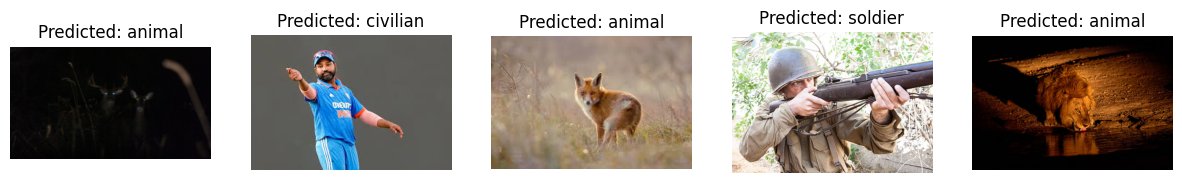

All results saved and zipped as classification_results.zip


In [6]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from glob import glob
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Create output directory
output_dir = "classification"
os.makedirs(output_dir, exist_ok=True)

# Load Dataset
def load_dataset(path, category):
    images, labels = [], []
    img_paths = glob(os.path.join(path, '**', '*.jpg'), recursive=True)
    img_paths.extend(glob(os.path.join(path, '**', '*.png'), recursive=True))
    
    for img_path in img_paths:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(category)
    return images, labels

# Data Transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset Paths
base_path = '/kaggle/input/defence-dataset/Dataset/Classification'
datasets = {
    "Day Animal": load_dataset(os.path.join(base_path, 'Day/animal'), 'animal'),
    "Day Civilian": load_dataset(os.path.join(base_path, 'Day/human/civilian'), 'civilian'),
    "Day Soldier": load_dataset(os.path.join(base_path, 'Day/human/soldier'), 'soldier'),
    "Night Animal": load_dataset(os.path.join(base_path, 'Night/animal'), 'animal')
}

# Prepare Training Data
train_images, train_labels = [], []
for images, labels in datasets.values():
    train_images.extend(images[:400])  
    train_labels.extend(labels[:400])

# Prepare DataLoader
class DefenceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

dataset = DefenceDataset(train_images, train_labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Load Pretrained Model
model_name = "google/efficientnet-b0"
model = AutoModelForImageClassification.from_pretrained(
    model_name, 
    num_labels=3, 
    id2label={0: "animal", 1: "civilian", 2: "soldier"}, 
    label2id={"animal": 0, "civilian": 1, "soldier": 2},
    ignore_mismatched_sizes=True
)

# Training Function
def train_model(model, dataloader, epochs=10, lr=1e-5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=1e-6, max_lr=1e-4, step_size_up=10, mode='triangular')
    loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.2)

    train_loss = []
    train_accuracy = []
    learning_rates = []

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in dataloader:
            images = images.to(device)
            labels = torch.tensor([model.config.label2id[label] for label in labels], dtype=torch.long).to(device)
            
            optimizer.zero_grad()
            outputs = model(images).logits
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        
        avg_loss = running_loss / len(dataloader)
        accuracy = correct / total
        
        train_loss.append(avg_loss)
        train_accuracy.append(accuracy)
        learning_rates.append(optimizer.param_groups[0]["lr"])
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    print("Training complete.")
    model_path = os.path.join(output_dir, "defence_efficientnet.pth")
    torch.save(model.state_dict(), model_path)

    # Save Plots
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(train_loss, marker='o', color='r')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.savefig(os.path.join(output_dir, "loss_plot.png"))

    plt.subplot(1, 3, 2)
    plt.plot(train_accuracy, marker='o', color='g')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.savefig(os.path.join(output_dir, "accuracy_plot.png"))

    plt.subplot(1, 3, 3)
    plt.plot(learning_rates, marker='o', color='b')
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rate Schedule")
    plt.savefig(os.path.join(output_dir, "learning_rate_plot.png"))

    plt.close()

# Testing Function
def test_model(model, test_images):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    
    fig, axes = plt.subplots(1, len(test_images), figsize=(15, 5))
    for i, img in enumerate(test_images):
        transformed_img = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(transformed_img).logits
            pred = torch.argmax(outputs, dim=1).item()
            pred_label = model.config.id2label[pred]

        image_path = os.path.join(output_dir, f"test_image_{i}.png")
        plt.imsave(image_path, img)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Predicted: {pred_label}")
        axes[i].axis("off")
    plt.savefig(os.path.join(output_dir, "test_results.png"))
    plt.show()

# Train Model
train_model(model, dataloader)

# Select Test Images & Run Model
test_images = [train_images[i] for i in np.random.choice(len(train_images), 5, replace=False)]
test_model(model, test_images)

# Zip Everything
zip_filename = "classification_results.zip"
with zipfile.ZipFile(zip_filename, "w") as zipf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), output_dir))

print(f"All results saved and zipped as {zip_filename}")


Civilian Images: 50
Soldier Images: 50


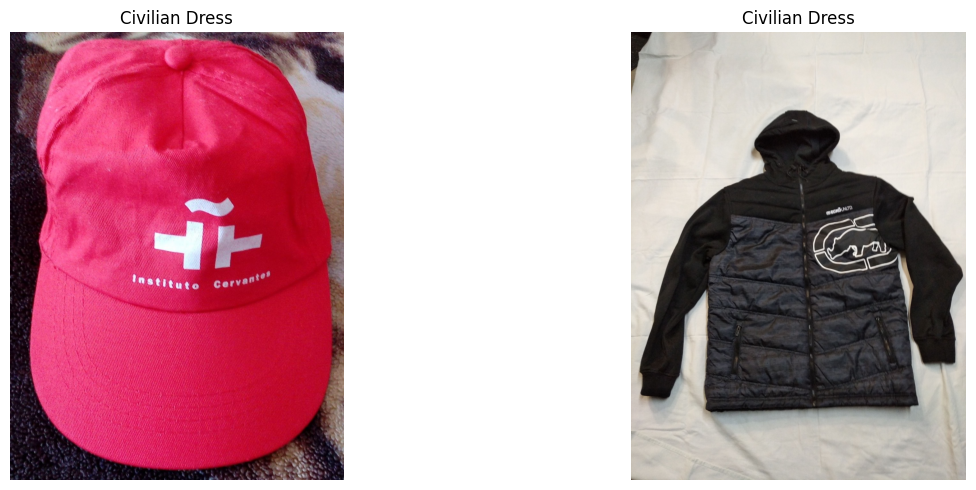

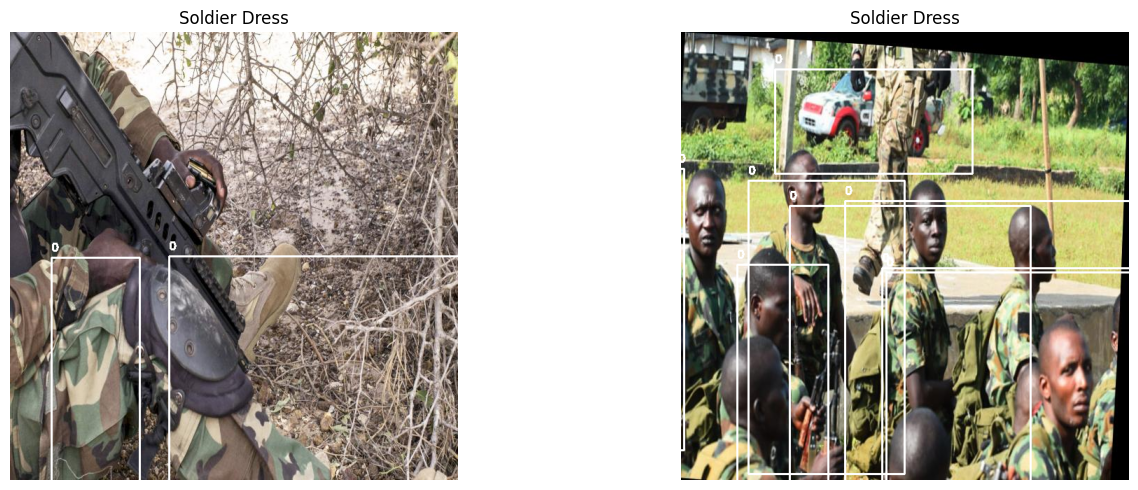

In [7]:
import os
import cv2 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob

def parse_txt(txt_path):
    boxes = []
    if not os.path.exists(txt_path):
        return boxes
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_name = parts[0]
                coords = [float(x) for x in parts[1:5]]
                boxes.append({'class': class_name, 'coords': coords})
    return boxes

def load_images_and_labels(image_path, label_path, category, max_images=100):
    images, labels = [], []
    img_paths = glob(os.path.join(image_path, '*.jpg')) + glob(os.path.join(image_path, '*.png'))
    img_paths = img_paths[:max_images]  # Limit the number of images to reduce memory usage
    
    for img_path in img_paths:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
            txt_path = os.path.join(label_path, os.path.basename(img_path).replace('.jpg', '.txt').replace('.png', '.txt'))
            boxes = parse_txt(txt_path)
            labels.append(boxes if boxes else None)
    return images, labels

def draw_boxes(img, boxes):
    img_copy = img.copy()
    img_height, img_width = img.shape[:2]
    
    colors = {'civilian': (0, 255, 0), 'soldier': (0, 0, 255)}
    
    for box in boxes:
        coords = box['coords']
        class_name = box['class'].lower()
        color = colors.get(class_name, (255, 255, 255))
        
        x_center, y_center, width, height = coords
        if x_center <= 1.0:
            x_center *= img_width
            y_center *= img_height
            width *= img_width
            height *= img_height
        
        x1, y1 = int(x_center - width/2), int(y_center - height/2)
        x2, y2 = int(x_center + width/2), int(y_center + height/2)
        
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_copy, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return img_copy

def display_samples(images, labels, category, num_samples=3):
    if not images:
        print(f"No images found for {category}")
        return
    
    num_samples = min(num_samples, len(images))  # Ensure we don't select more than available images
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        img = images[idx]
        if labels[idx]:
            img = draw_boxes(img, labels[idx])
        axes[i].imshow(img)
        axes[i].set_title(category)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

base_path = '/kaggle/input/defence-dataset/Dataset/dresses'

civilian_images, civilian_labels = load_images_and_labels(
    os.path.join(base_path, 'civilians/images_original'),
    os.path.join(base_path, 'civilians/images.csv'),
    'civilian',
    max_images=50  # Reduce memory usage
)

soldier_images, soldier_labels = load_images_and_labels(
    os.path.join(base_path, 'soldiers/images'),
    os.path.join(base_path, 'soldiers/labels'),
    'soldier',
    max_images=50  # Reduce memory usage
)

print(f"Civilian Images: {len(civilian_images)}")
print(f"Soldier Images: {len(soldier_images)}")

display_samples(civilian_images, civilian_labels, "Civilian Dress", num_samples=2)
display_samples(soldier_images, soldier_labels, "Soldier Dress", num_samples=2)


In [8]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.7/914.7 kB 14.9 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install -U "ray[tune]"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
import cv2
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from glob import glob
from tqdm import tqdm
from ultralytics import YOLO
import random
import shutil
import matplotlib.pyplot as plt
from PIL import Image
import zipfile

# Define paths
OUTPUT_DIR = "/kaggle/working/dresses"
CIVILIAN_PATH = "/kaggle/input/defence-dataset/Dataset/dresses/civilians/images_original"
SOLDIER_PATH = "/kaggle/input/defence-dataset/Dataset/dresses/soldiers/images"
DATASET_PATH = os.path.join(OUTPUT_DIR, "dataset")
IMAGE_PATH = os.path.join(DATASET_PATH, "images")
LABELS_PATH = os.path.join(DATASET_PATH, "labels")
TRAIN_PATH = os.path.join(IMAGE_PATH, "train")
VAL_PATH = os.path.join(IMAGE_PATH, "val")
TRAIN_LABELS_PATH = os.path.join(LABELS_PATH, "train")
VAL_LABELS_PATH = os.path.join(LABELS_PATH, "val")
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "yolo_model.pt")
PLOT_SAVE_PATH = os.path.join(OUTPUT_DIR, "training_plots.png")
ZIP_FILE_PATH = "/kaggle/working/dresses.zip"

# Create necessary directories
os.makedirs(TRAIN_PATH, exist_ok=True)
os.makedirs(VAL_PATH, exist_ok=True)
os.makedirs(TRAIN_LABELS_PATH, exist_ok=True)
os.makedirs(VAL_LABELS_PATH, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load images
civilian_images = glob(os.path.join(CIVILIAN_PATH, "*.jpg"))
soldier_images = glob(os.path.join(SOLDIER_PATH, "*.jpg"))
all_images = civilian_images + soldier_images

# Split data into train and val
random.shuffle(all_images)
split_idx = int(0.8 * len(all_images))
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

for img in train_images:
    shutil.copy(img, TRAIN_PATH)
for img in val_images:
    shutil.copy(img, VAL_PATH)

# Transform for feature extraction
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load EfficientNet-B0 for feature extraction
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).to(device)
model.eval()

# Extract features
features = []
image_paths = []
print("Extracting features...")
for img_path in tqdm(all_images):
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feature = model(img).squeeze().cpu().numpy()
    features.append(feature)
    image_paths.append(img_path)
features = np.array(features)

# Apply K-Means Clustering
print("Clustering images into 2 groups...")
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
labels = kmeans.fit_predict(features)

# Save labels as YOLO format
for img_path, label in zip(image_paths, labels):
    base_name = os.path.basename(img_path)
    label_file = os.path.join(TRAIN_LABELS_PATH if img_path in train_images else VAL_LABELS_PATH, base_name.replace(".jpg", ".txt"))
    with open(label_file, "w") as f:
        f.write(f"{label} 0.5 0.5 1.0 1.0\n")
print("Labels generated successfully!")

# Create data.yaml
data_yaml = f"""
train: {TRAIN_PATH}
val: {VAL_PATH}
nc: 2
names: ["civilian", "soldier"]
"""
with open(DATA_YAML, "w") as f:
    f.write(data_yaml)

# Train YOLO model
print("Training YOLOv8 model...")
yolo_model = YOLO("yolov8n.pt")
results = yolo_model.train(data=DATA_YAML, epochs=5, batch=16, imgsz=640)

# Extract training logs
train_loss = results.results["train_loss"]
val_loss = results.results["val_loss"]
mAP50 = results.results["metrics/mAP_50"]
mAP50_95 = results.results["metrics/mAP_50-95"]

# Plot training metrics
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(mAP50, label='mAP@50', color='green')
plt.xlabel('Epochs')
plt.ylabel('mAP')
plt.title('mAP@50')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(mAP50_95, label='mAP@50-95', color='red')
plt.xlabel('Epochs')
plt.ylabel('mAP')
plt.title('mAP@50-95')
plt.legend()

plt.tight_layout()
plt.savefig(PLOT_SAVE_PATH)
print(f"Training plots saved at {PLOT_SAVE_PATH}")

# Save trained model
yolo_model.export(format="torchscript")
shutil.move("yolov8n.torchscript", MODEL_SAVE_PATH)
print(f"Model saved at {MODEL_SAVE_PATH}")

# Zip all results
with zipfile.ZipFile(ZIP_FILE_PATH, 'w') as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, OUTPUT_DIR)
            zipf.write(file_path, arcname)
print(f"All results saved in {ZIP_FILE_PATH}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 131MB/s]


Extracting features...


100%|██████████| 5891/5891 [15:39<00:00,  6.27it/s]


Clustering images into 2 groups...
Labels generated successfully!
Training YOLOv8 model...


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 37/37 [03:55<00:00,  6.37s/it]


                   all       1179       1179      0.925      0.896      0.962      0.953
              civilian        207        207      0.932      0.796      0.933      0.918
               soldier        972        972      0.919      0.996       0.99      0.987


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 4.6ms preprocess, 137.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/train


AttributeError: 'DetMetrics' object has no attribute 'results'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP) of an
    object detection model.

    Args:
        save_dir (Path): A path to the directory where the output plots will be saved. Defaults to current directory.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class. Defaults to False.
        on_plot (func): An optional callback to pass plots path and data when they are rendered. Defaults to None.
        names (dict of str): A dict of strings that represents the names of the classes. Defaults to an empty tuple.

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot the precision-recall curves for each class.
        on_plot (func): An optional callback to pass plots path and data when

In [19]:
# Save trained model
yolo_model.export(format="torchscript")
shutil.move("yolov8n.torchscript", MODEL_SAVE_PATH)
print(f"Model saved at {MODEL_SAVE_PATH}")

# Zip all results
with zipfile.ZipFile(ZIP_FILE_PATH, 'w') as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, OUTPUT_DIR)
            zipf.write(file_path, arcname)
print(f"All results saved in {ZIP_FILE_PATH}")


TypeError: 'IterableSimpleNamespace' object is not subscriptable

In [24]:
import torch
import random
import glob
import os
import shutil
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the trained YOLO model
MODEL_SAVE_PATH = "/kaggle/working/runs/detect/train/weights/best.pt"
model = YOLO(MODEL_SAVE_PATH)

# Define image directories
CIVILIAN_PATH = "/kaggle/input/defence-dataset/Dataset/dresses/civilians/images_original"
SOLDIER_PATH = "/kaggle/input/defence-dataset/Dataset/dresses/soldiers/images"
OUTPUT_DIR = "/kaggle/working/yolo_outputs"
ZIP_PATH = "/kaggle/working/yolo_outputs.zip"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Get list of images
civilian_images = glob.glob(f"{CIVILIAN_PATH}/*.jpg")
soldier_images = glob.glob(f"{SOLDIER_PATH}/*.jpg")

# Randomly select images from both categories
test_images = random.sample(civilian_images, min(2, len(civilian_images))) + \
              random.sample(soldier_images, min(2, len(soldier_images)))

# Define label mapping (flipping the labels)
label_mapping = {0: "soldier", 1: "civilian"}  # Swap civilian ↔ soldier

for img in test_images:
    results = model(img, verbose=False)
    output_img_path = os.path.join(OUTPUT_DIR, os.path.basename(img))
    shutil.copy(img, output_img_path)  # Save input image

    # Modify results by flipping labels
    for result in results:
        if result.boxes is not None and len(result.boxes) > 0:
            new_boxes_data = result.boxes.data.clone()
            new_boxes_data[:, 5] = torch.tensor(
                [1 if cls == 0 else 0 for cls in result.boxes.cls.tolist()],
                dtype=result.boxes.cls.dtype,
                device=result.boxes.cls.device
            )
            result.boxes.data = new_boxes_data
    
    # Save output image
    plt.imshow(results[0].plot())
    plt.axis("off")
    output_img_save_path = os.path.join(OUTPUT_DIR, f"output_{os.path.basename(img)}")
    plt.savefig(output_img_save_path, bbox_inches='tight')
    plt.close()

# Zip the output directory
shutil.make_archive(OUTPUT_DIR, 'zip', OUTPUT_DIR)

print(f"All outputs saved and zipped at {ZIP_PATH}")

All outputs saved and zipped at /kaggle/working/yolo_outputs.zip


In [21]:
!zip -r /kaggle/working/runs.zip /kaggle/working/runs


  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/train5/ (stored 0%)
  adding: kaggle/working/runs/detect/train5/weights/ (stored 0%)
  adding: kaggle/working/runs/detect/train5/args.yaml (deflated 53%)
  adding: kaggle/working/runs/detect/train5/train_batch1.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/train5/labels_correlogram.jpg (deflated 73%)
  adding: kaggle/working/runs/detect/train5/train_batch2.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/train5/events.out.tfevents.1739255495.a0b50b9ac0b1.31.2 (deflated 94%)
  adding: kaggle/working/runs/detect/train5/labels.jpg (deflated 56%)
  adding: kaggle/working/runs/detect/train5/train_batch0.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/train4/ (stored 0%)
  adding: kaggle/working/runs/detect/train4/weights/ (stored 0%)
  adding: kaggle/working/runs/detect/train4/args.yaml (deflated 53%)
  adding: kaggle/working/runs/detect/tra

Civilian Images: 81
Soldier Images: 74


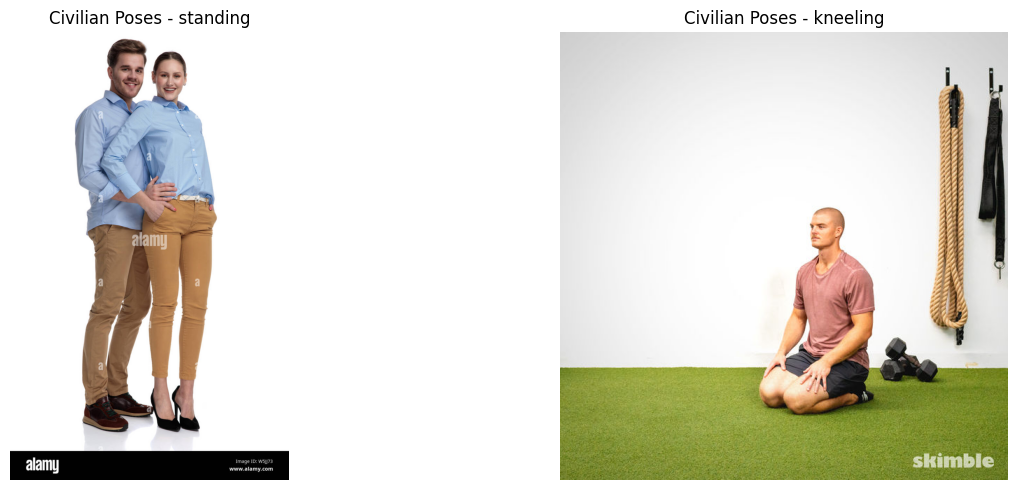

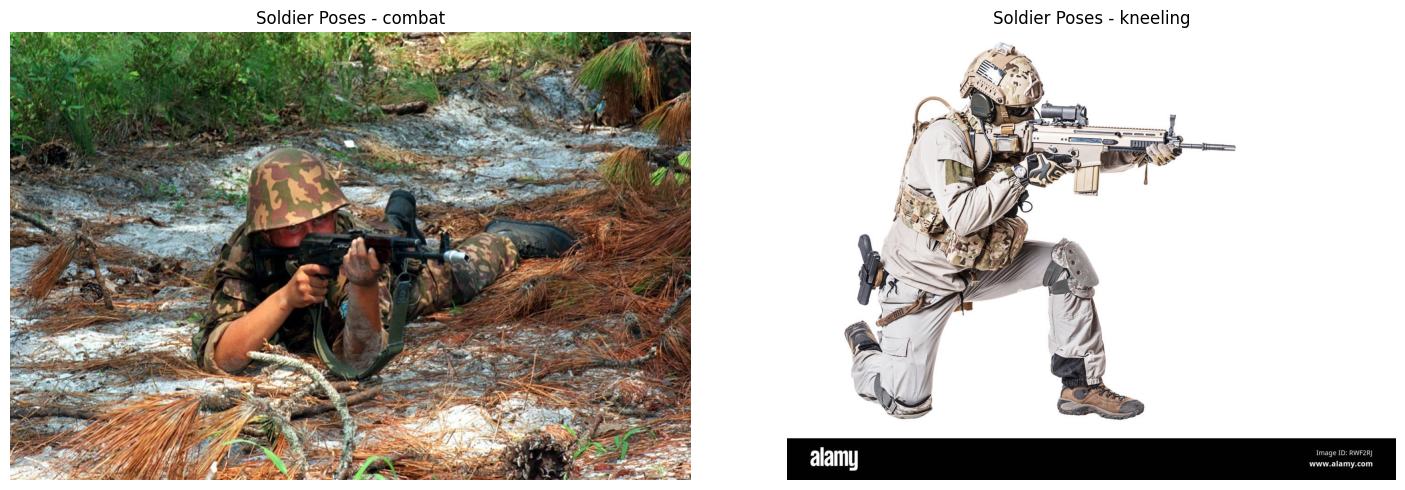

In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from glob import glob

def load_annotations(annotation_path):
    with open(annotation_path, 'r') as f:
        return json.load(f)

def load_images_and_labels(image_folders, annotation_data, category, max_images=20):
    images, labels, poses = [], [], []
    
    for folder in image_folders:
        pose_name = os.path.basename(folder)  # Extract pose name from folder structure
        img_paths = glob(os.path.join(folder, '*.jpg')) + glob(os.path.join(folder, '*.png'))
        img_paths = img_paths[:max_images]  # Limit the number of images to reduce memory usage
        
        for img_path in img_paths:
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                poses.append(pose_name)  # Store pose name
                
                img_name = os.path.basename(img_path)
                boxes = annotation_data.get(img_name, [])
                labels.append(boxes if boxes else None)
    
    return images, labels, poses

def draw_boxes(img, boxes, pose, override_label=None):
    img_copy = img.copy()
    img_height, img_width = img.shape[:2]
    
    colors = {'civilian': (0, 255, 0), 'soldier': (0, 0, 255), 'combat': (255, 0, 0)}
    
    for box in boxes:
        coords = box['coords']
        class_name = override_label if override_label else box['class'].lower()
        color = colors.get(class_name, (255, 255, 255))
        
        x_center, y_center, width, height = coords
        if x_center <= 1.0:
            x_center *= img_width
            y_center *= img_height
            width *= img_width
            height *= img_height
        
        x1, y1 = int(x_center - width/2), int(y_center - height/2)
        x2, y2 = int(x_center + width/2), int(y_center + height/2)
        
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
        label_text = f"{class_name} ({pose})"
        cv2.putText(img_copy, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return img_copy

def display_samples(images, labels, poses, category, override_label=None, num_samples=3):
    if not images:
        print(f"No images found for {category}")
        return
    
    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        img = images[idx]
        pose = poses[idx]
        if labels[idx]:
            img = draw_boxes(img, labels[idx], pose, override_label)
        axes[i].imshow(img)
        axes[i].set_title(f"{category} - {pose}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

base_path = '/kaggle/input/defence-dataset/Dataset/poses'
annotation_path = os.path.join(base_path, 'annotations/pose_annotations.json')
annotations = load_annotations(annotation_path)

civilian_folders = [
    os.path.join(base_path, 'civilian/kneeling'),
    os.path.join(base_path, 'civilian/running'),
    os.path.join(base_path, 'civilian/sitting'),
    os.path.join(base_path, 'civilian/standing'),
    os.path.join(base_path, 'civilian/walking')
]

soldier_folders = [
    os.path.join(base_path, 'soldier/combat'),
    os.path.join(base_path, 'soldier/kneeling'),
    os.path.join(base_path, 'soldier/running'),
    os.path.join(base_path, 'soldier/standing')
]

civilian_images, civilian_labels, civilian_poses = load_images_and_labels(civilian_folders, annotations, 'civilian', max_images=20)
soldier_images, soldier_labels, soldier_poses = load_images_and_labels(soldier_folders, annotations, 'soldier', max_images=20)

print(f"Civilian Images: {len(civilian_images)}")
print(f"Soldier Images: {len(soldier_images)}")

display_samples(civilian_images, civilian_labels, civilian_poses, "Civilian Poses", num_samples=2)
display_samples(soldier_images, soldier_labels, soldier_poses, "Soldier Poses", override_label="combat" if 'combat' in soldier_folders else None, num_samples=2)


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models.segmentation as models
from torch.utils.data import DataLoader, Dataset
from PIL import Image, UnidentifiedImageError
import os
import numpy as np
import matplotlib.pyplot as plt
import shutil

# Define dataset class
class BodyPartDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = os.listdir(image_dir)
        self.transform = transform
        self.body_parts = ["head", "left_arm", "left_hand", "left_leg", "right_hand", "right_arm", "right_leg", "torso"]
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        base_name = os.path.splitext(self.image_filenames[idx])[0]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError):
            print(f"Warning: Skipping invalid image {img_path}")
            return self.__getitem__((idx + 1) % len(self))  # Get next image instead
        
        mask = np.zeros((256, 256), dtype=np.uint8)
        
        for i, part in enumerate(self.body_parts, start=1):
            part_mask_path = os.path.join(self.mask_dir, base_name, f"{part}.png")
            if os.path.exists(part_mask_path):
                part_mask = Image.open(part_mask_path).resize((256, 256))
                part_mask = np.array(part_mask) > 0
                mask[part_mask] = i
        
        if self.transform:
            image = self.transform(image)
            mask = torch.tensor(mask, dtype=torch.long)
        
        return image, mask, base_name

# Define paths
data_dir = "/kaggle/input/defence-dataset/Dataset/Body parts/soldier"
image_dir = os.path.join(data_dir, "images")
mask_dir = os.path.join(data_dir, "masks")

# Define transforms
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
dataset = BodyPartDataset(image_dir, mask_dir, transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Load DeepLabV3 model
model = models.deeplabv3_resnet50(weights=models.DeepLabV3_ResNet50_Weights.DEFAULT)
model.classifier[4] = nn.Conv2d(256, len(dataset.body_parts) + 1, kernel_size=1)  # Adjust for num classes

# Move model to CPU
model = model.cpu()

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, masks, _ in dataloader:
        images, masks = images.cpu(), masks.cpu()
        optimizer.zero_grad()
        outputs = model(images)['out']
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataloader)}")

# Save model
model_path = "deeplabv3_soldier.pth"
torch.save(model.state_dict(), model_path)

# Create directory for saving output images
output_dir = "output_images"
os.makedirs(output_dir, exist_ok=True)

# Function to visualize and save outputs
def visualize_and_save(image_path, base_name):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).cpu()
    
    with torch.no_grad():
        output = model(input_tensor)['out']
        pred_mask = torch.argmax(output, dim=1).cpu().squeeze(0).numpy()

    # Save the output mask
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask, cmap='jet')
    plt.title("Predicted Mask")

    output_path = os.path.join(output_dir, f"{base_name}_output.png")
    plt.savefig(output_path)
    plt.close()

# Process all images and save outputs
for idx in range(len(dataset)):
    _, _, base_name = dataset[idx]
    image_path = os.path.join(image_dir, f"{base_name}.jpg")  # Adjust extension if needed
    if os.path.exists(image_path):
        visualize_and_save(image_path, base_name)

# Create a ZIP file with model and output images
zip_path = "body_parts.zip"
with shutil.ZipFile(zip_path, 'w') as zipf:
    zipf.write(model_path)  # Add model
    for file in os.listdir(output_dir):  # Add images
        zipf.write(os.path.join(output_dir, file), os.path.join("output_images", file))

print(f"Saved model and outputs in {zip_path}")
